# Notebook 07a - Euro 2024 Team Tactical Analysis
### Mirroring Notebook 04: Territory, Passing Structure, Progression, Pressing

This notebook is the direct mirror of Notebook 04 for Euro 2024. Every metric uses the identical definitions from the 2022 analysis.

In [1]:
import pandas as pd, numpy as np, os, sys
import matplotlib.pyplot as plt, matplotlib.patheffects as pe
from mplsoccer import Pitch, VerticalPitch
import warnings; warnings.filterwarnings('ignore')
os.makedirs('../outputs/figures/2024', exist_ok=True)
sys.path.insert(0, os.path.abspath('..'))
from utils.config import OUTPUTS_DATA_DIR
df = pd.read_parquet(os.path.join(OUTPUTS_DATA_DIR, 'master_events_cleaned.parquet'))
s24 = df[(df['tournament']=='EURO2024')&(df['team']=='Spain')].copy()
o24 = df[(df['tournament']=='EURO2024')&(df['team']!='Spain')].copy()
s22 = df[(df['tournament']=='WC2022')&(df['team']=='Spain')].copy()
n22, n24 = s22['match_id'].nunique(), s24['match_id'].nunique()
print(f'WC2022: {n22} matches, {len(s22)} events')
print(f'EURO2024: {n24} matches, {len(s24)} events')

WC2022: 4 matches, 12322 events
EURO2024: 7 matches, 15052 events


---
## 1. Territory Heatmaps (2022 vs 2024)
Where did the ball live? Direct comparison of possession territory.

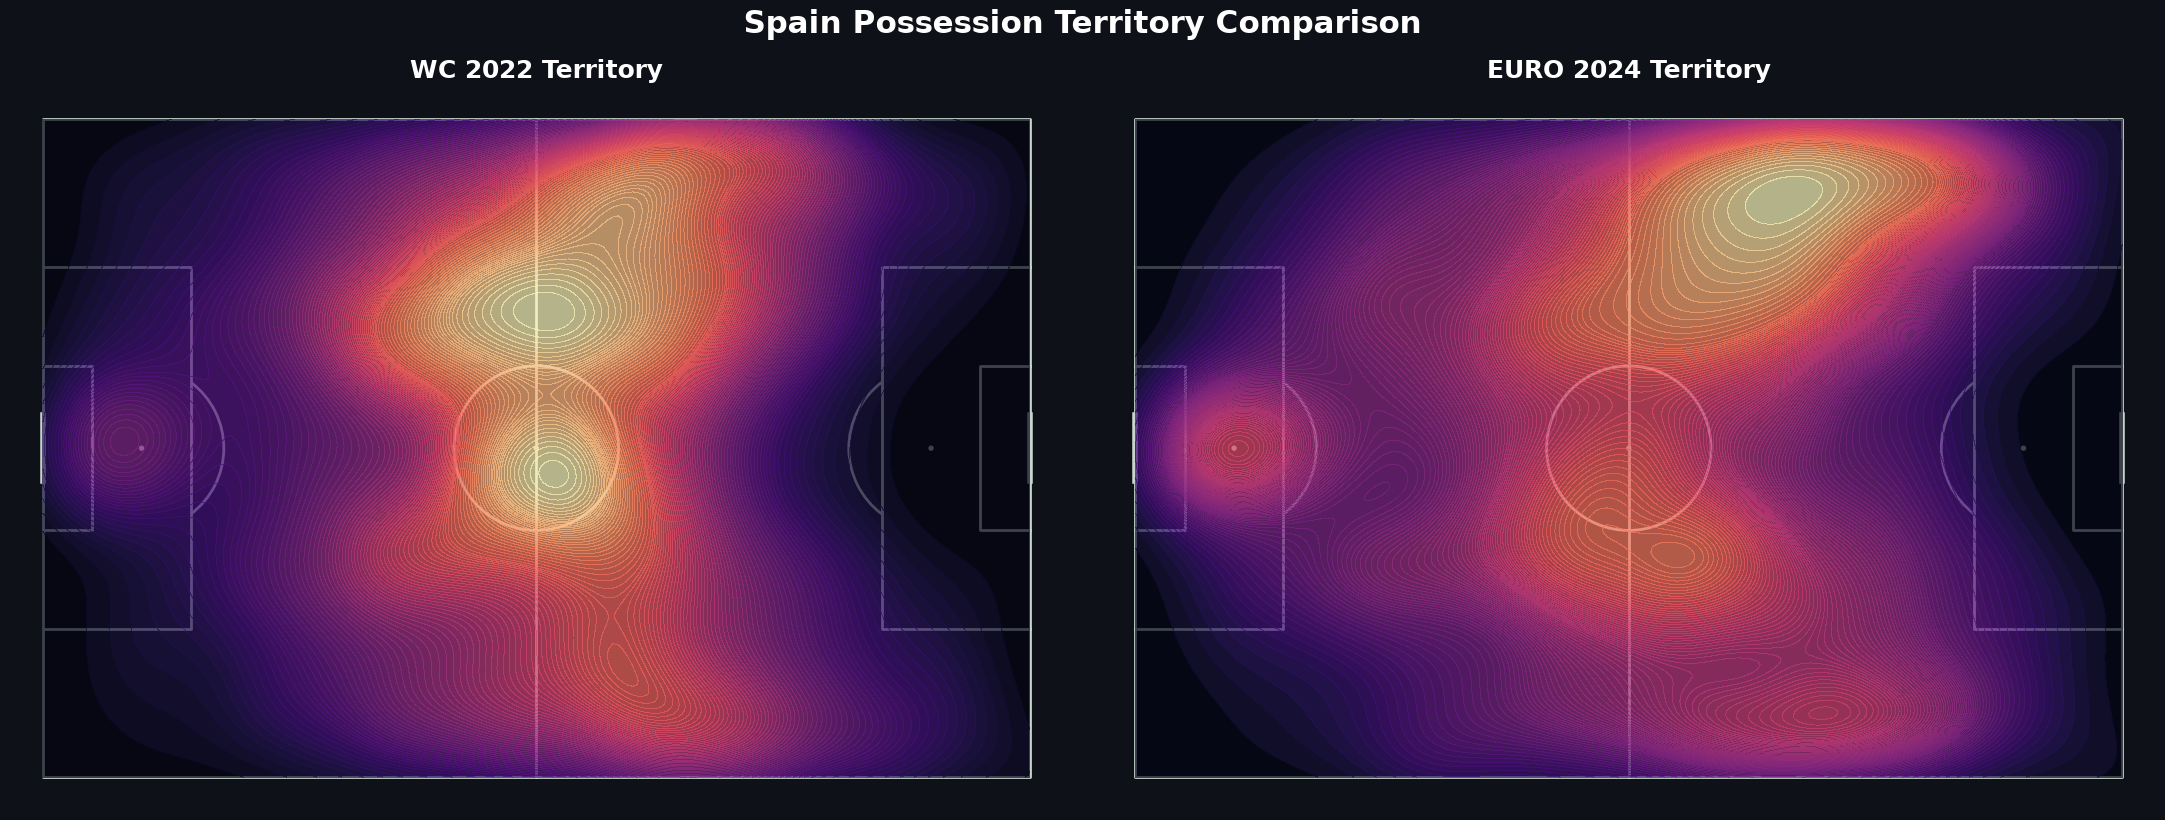

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(22,8), facecolor='#0e1117')
for i, (tag, sdf) in enumerate([('WC 2022', s22), ('EURO 2024', s24)]):
    t = sdf[sdf['type'].isin(['Pass','Carry','Dribble'])].dropna(subset=['x','y'])
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#0e1117', line_color='#c7d5cc')
    pitch.draw(ax=axes[i])
    pitch.kdeplot(t['x'], t['y'], ax=axes[i], fill=True, levels=100, thresh=0, cut=4, cmap='magma', alpha=0.7)
    axes[i].set_title(f'{tag} Territory', color='white', fontsize=18, fontweight='bold')
fig.suptitle('Spain Possession Territory Comparison', color='white', fontsize=22, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/2024/viz50_territory_comparison.png', dpi=200, bbox_inches='tight', facecolor='#0e1117')
plt.show()

---
## 2. Passing Network (Euro 2024)
How did the buildup structure change? Who were the hubs?

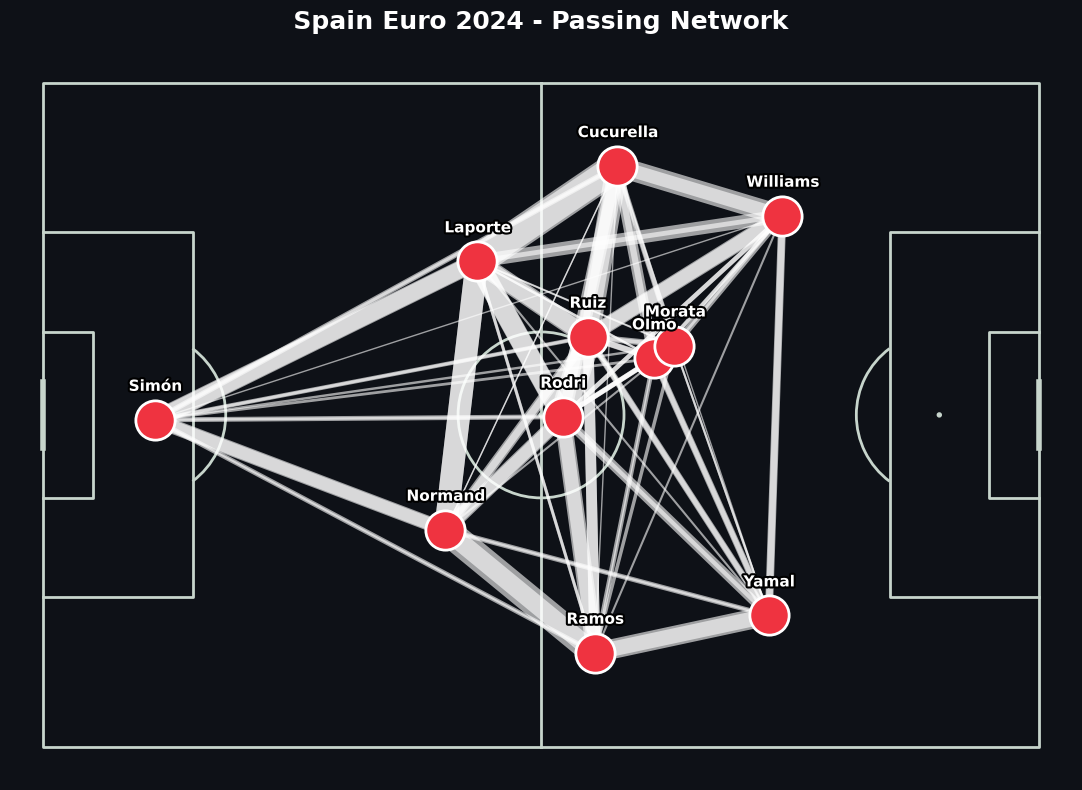


Buildup Centrality (Top 5 by pass involvement):
  Laporte: 369.0 passes (15.0% of network)
  Fabián Ruiz: 335.0 passes (13.6% of network)
  Rodri: 332.0 passes (13.5% of network)
  Cucurella: 315.0 passes (12.8% of network)
  Le Normand: 266.0 passes (10.8% of network)


In [3]:
starters = s24['common_name'].fillna(s24['player']).value_counts().head(11).index.tolist()
passes = s24[(s24['type']=='Pass')&(s24['pass_outcome'].isna())].copy()
passes['p'] = passes['common_name'].fillna(passes['player'])
passes['r'] = passes['pass_recipient'].map(lambda x: s24[s24['player']==x]['common_name'].iloc[0] if len(s24[s24['player']==x])>0 and pd.notna(s24[s24['player']==x]['common_name'].iloc[0]) else x)
passes = passes[passes['p'].isin(starters)&passes['r'].isin(starters)]
avg = passes.groupby('p').agg(x=('x','mean'),y=('y','mean'),cnt=('x','count'))
combos = passes.groupby(['p','r']).size().reset_index(name='n')
combos = combos[(combos['n']>3)&combos['p'].isin(avg.index)&combos['r'].isin(avg.index)]
pitch = Pitch(pitch_type='statsbomb', pitch_color='#0e1117', line_color='#c7d5cc')
fig, ax = pitch.draw(figsize=(12,8)); fig.set_facecolor('#0e1117')
for _, r in combos.iterrows():
    if r['p'] in avg.index and r['r'] in avg.index:
        pitch.lines(avg.loc[r['p'],'x'], avg.loc[r['p'],'y'], avg.loc[r['r'],'x'], avg.loc[r['r'],'y'], ax=ax, color='white', lw=r['n']/4, alpha=0.6, zorder=1)
pitch.scatter(avg['x'], avg['y'], s=800, color='#ef3340', edgecolors='white', lw=2, ax=ax, zorder=2)
for name, r in avg.iterrows():
    label = str(name).split()[-1] if len(str(name).split())>1 else str(name)
    ax.annotate(label, (r['x'], r['y']-3.5), color='white', ha='center', fontsize=11, fontweight='bold', zorder=3, path_effects=[pe.withStroke(linewidth=3, foreground='black')])
ax.set_title('Spain Euro 2024 - Passing Network', color='white', fontsize=18, fontweight='bold', pad=15)
plt.savefig('../outputs/figures/2024/viz51_pass_network_2024.png', dpi=200, bbox_inches='tight', facecolor='#0e1117')
plt.show()
print('\nBuildup Centrality (Top 5 by pass involvement):')
for name, r in avg.sort_values('cnt', ascending=False).head(5).iterrows():
    print(f'  {name}: {r["cnt"]} passes ({r["cnt"]/avg["cnt"].sum()*100:.1f}% of network)')

---
## 3. Progressive Pass Map (Euro 2024)

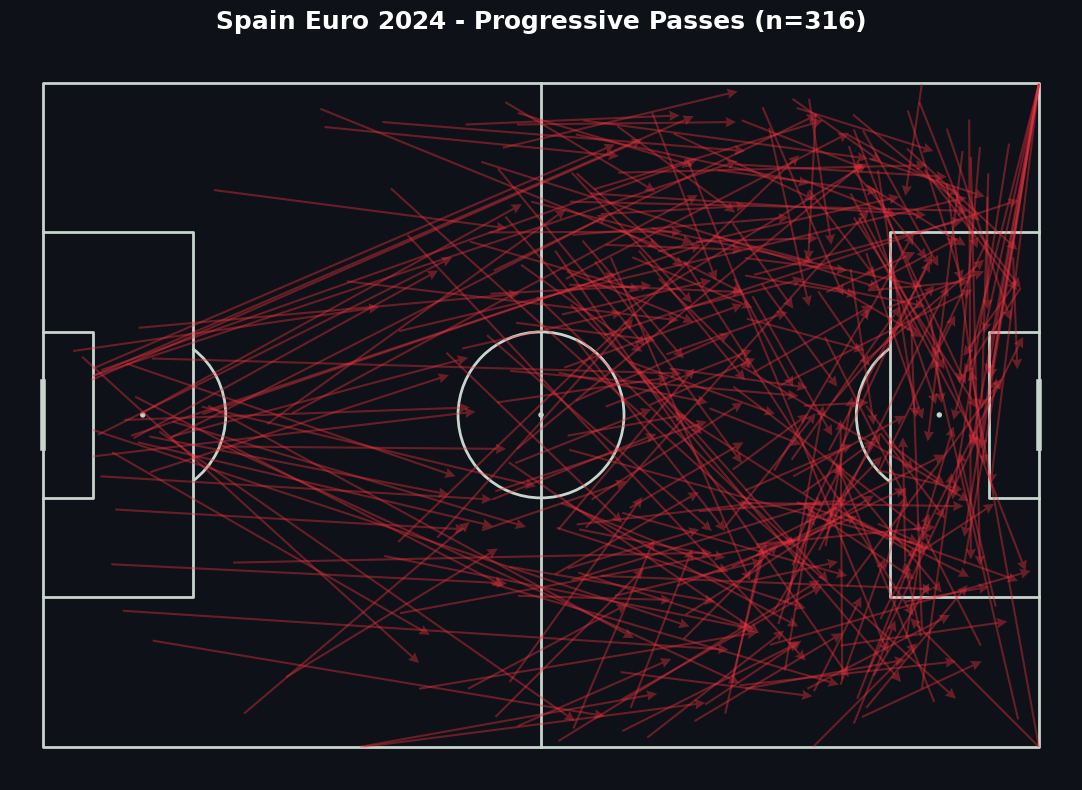

In [4]:
pp = s24[s24['is_progressive_pass']==True].dropna(subset=['x','y','pass_end_x','pass_end_y'])
pitch = Pitch(pitch_type='statsbomb', pitch_color='#0e1117', line_color='#c7d5cc')
fig, ax = pitch.draw(figsize=(12,8)); fig.set_facecolor('#0e1117')
pitch.arrows(pp['x'], pp['y'], pp['pass_end_x'], pp['pass_end_y'], width=1.5, headwidth=5, headlength=5, color='#ef3340', ax=ax, alpha=0.4)
ax.set_title(f'Spain Euro 2024 - Progressive Passes (n={len(pp)})', color='white', fontsize=18, fontweight='bold', pad=15)
plt.savefig('../outputs/figures/2024/viz54_progressive_passes.png', dpi=200, bbox_inches='tight', facecolor='#0e1117')
plt.show()

---
## 4. Progressive Carry Map (Euro 2024)
The rise of the dribblers - Yamal and Williams carrying the ball forward.

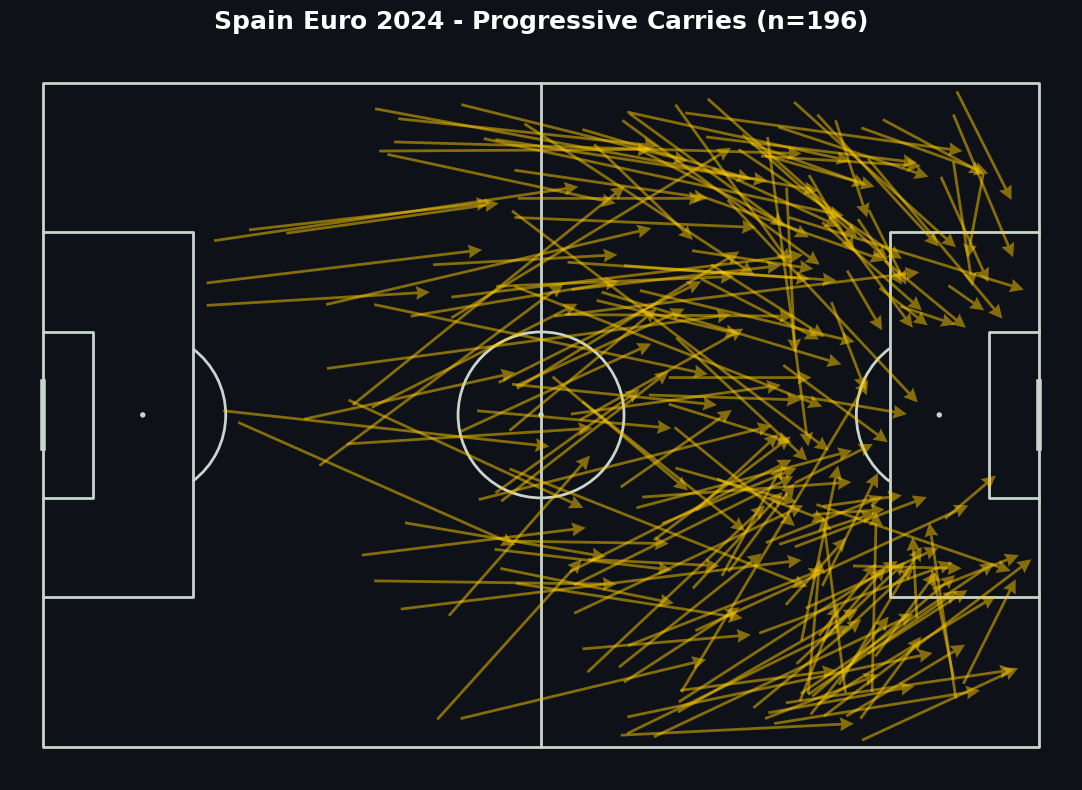

In [5]:
pc = s24[s24['is_progressive_carry']==True].dropna(subset=['x','y','carry_end_x','carry_end_y'])
pitch = Pitch(pitch_type='statsbomb', pitch_color='#0e1117', line_color='#c7d5cc')
fig, ax = pitch.draw(figsize=(12,8)); fig.set_facecolor('#0e1117')
pitch.arrows(pc['x'], pc['y'], pc['carry_end_x'], pc['carry_end_y'], width=2, headwidth=5, headlength=5, color='#fcca03', ax=ax, alpha=0.5)
ax.set_title(f'Spain Euro 2024 - Progressive Carries (n={len(pc)})', color='white', fontsize=18, fontweight='bold', pad=15)
plt.savefig('../outputs/figures/2024/viz55_progressive_carries.png', dpi=200, bbox_inches='tight', facecolor='#0e1117')
plt.show()

---
## 5. Pressing Heatmap (Euro 2024)
Did Spain press higher in 2024?

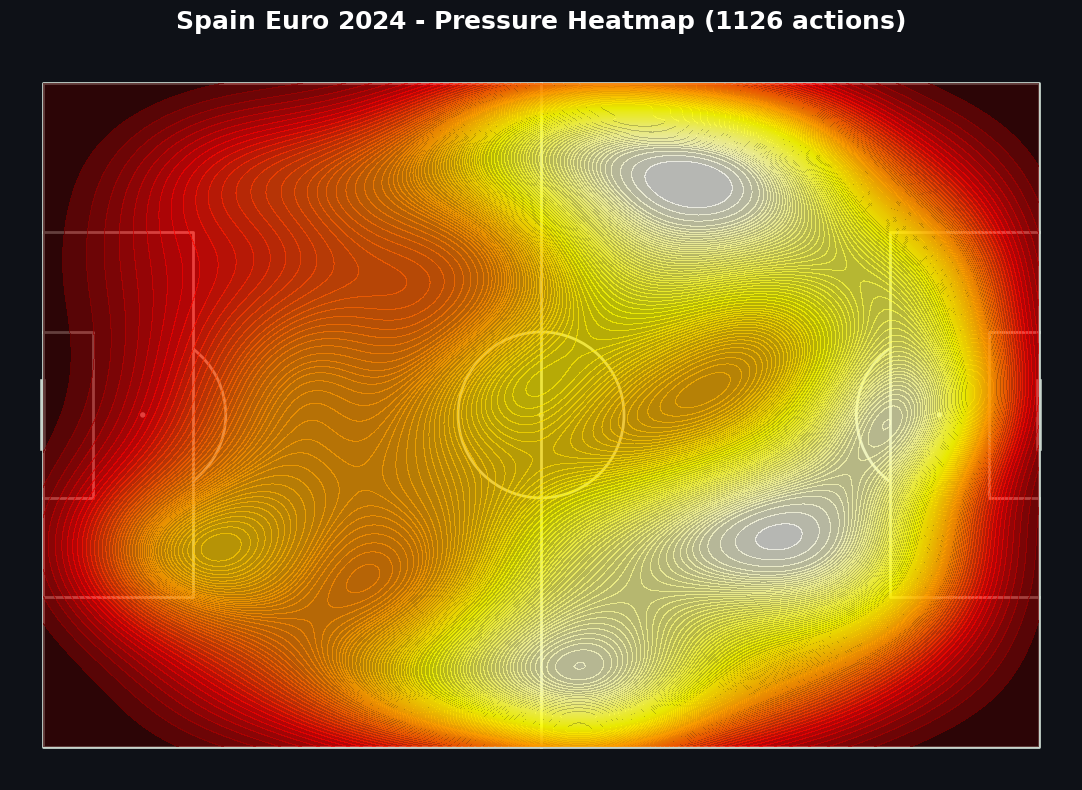

Average Pressure Height: 65.1 yards from own goal


In [6]:
press = s24[s24['type']=='Pressure'].dropna(subset=['x','y'])
pitch = Pitch(pitch_type='statsbomb', pitch_color='#0e1117', line_color='#c7d5cc')
fig, ax = pitch.draw(figsize=(12,8)); fig.set_facecolor('#0e1117')
pitch.kdeplot(press['x'], press['y'], ax=ax, fill=True, levels=100, thresh=0, cut=4, cmap='hot', alpha=0.7)
ax.set_title(f'Spain Euro 2024 - Pressure Heatmap ({len(press)} actions)', color='white', fontsize=18, fontweight='bold', pad=15)
plt.savefig('../outputs/figures/2024/viz56_pressure.png', dpi=200, bbox_inches='tight', facecolor='#0e1117')
plt.show()
print(f'Average Pressure Height: {press["x"].mean():.1f} yards from own goal')

---
## 6. Final Third Entry Zones (2022 vs 2024)
Did Spain really attack wider or more centrally in 2024?

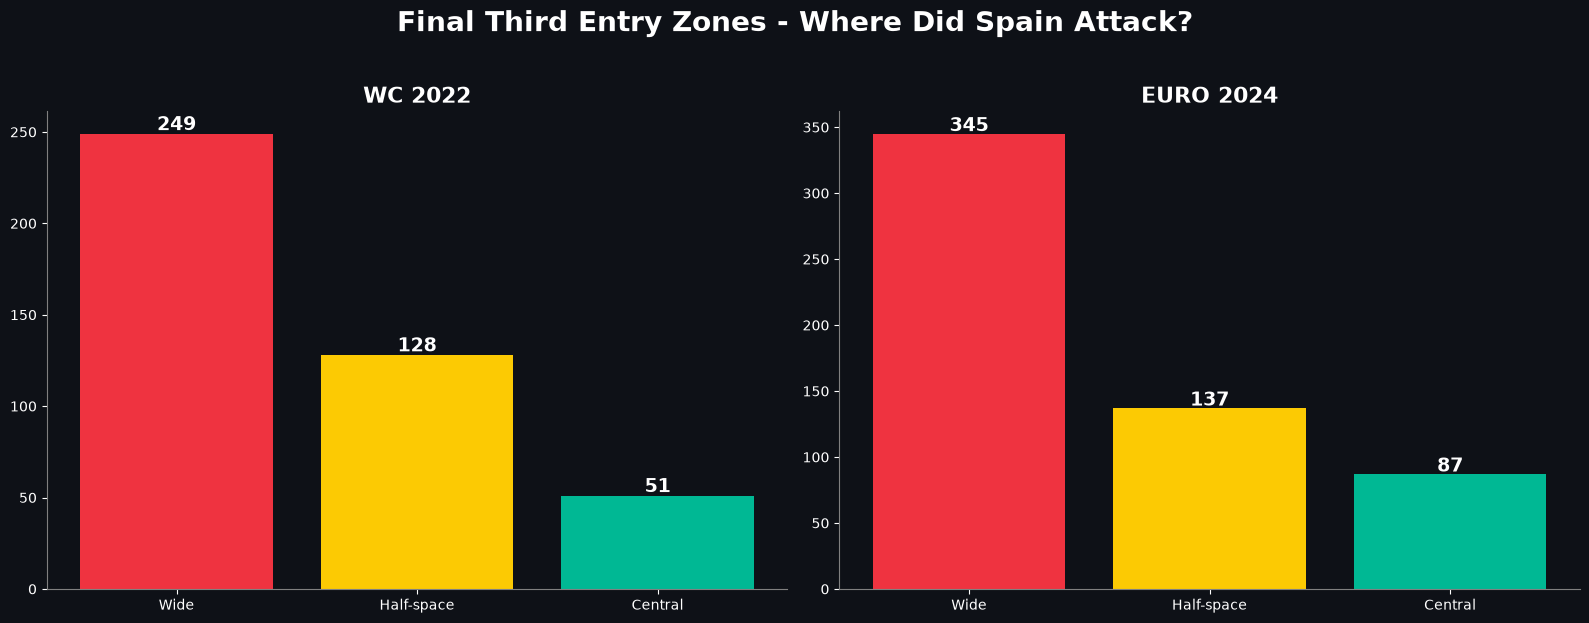

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16,6), facecolor='#0e1117')
for i, (tag, sdf, ax) in enumerate([('WC 2022', s22, axes[0]), ('EURO 2024', s24, axes[1])]):
    ax.set_facecolor('#0e1117')
    ft = sdf[sdf['type'].isin(['Pass','Carry'])].dropna(subset=['x','pass_end_x','carry_end_x'], how='all').copy()
    ft['ex'] = ft['pass_end_x'].fillna(ft['carry_end_x']); ft['ey'] = ft['pass_end_y'].fillna(ft['carry_end_y'])
    f3 = ft[(ft['x']<80)&(ft['ex']>=80)]
    wide = len(f3[(f3['ey']<18)|(f3['ey']>62)]); central = len(f3[(f3['ey']>=30)&(f3['ey']<=50)]); half = len(f3)-wide-central
    bars = ax.bar(['Wide','Half-space','Central'], [wide, half, central], color=['#ef3340','#fcca03','#00b894'])
    ax.set_title(f'{tag}', color='white', fontsize=16, fontweight='bold')
    ax.tick_params(colors='white')
    for s in ax.spines.values(): s.set_color('gray')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, str(int(bar.get_height())), ha='center', color='white', fontsize=14, fontweight='bold')
fig.suptitle('Final Third Entry Zones - Where Did Spain Attack?', color='white', fontsize=20, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('../outputs/figures/2024/viz60_f3_zones.png', dpi=200, bbox_inches='tight', facecolor='#0e1117')
plt.show()